In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

sns.set_theme(style="darkgrid", palette="deep")

plt.rcParams.update({
    "axes.grid": True,
    "axes.grid.which": "both",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.35,
    "grid.linewidth": 0.6,
})

In [2]:
# Крок 1. Первинний аналіз даних
# Спершу завантажуємо два датасети окремо (роздільник ";") і порівнюємо їх,
# перш ніж приймати рішення про об'єднання
red = pd.read_csv("winequality-red.csv", sep=";")
white = pd.read_csv("winequality-white.csv", sep=";")
print("red:", red.shape, "| white:", white.shape)
print("однаковий набір колонок:", list(red.columns) == list(white.columns))
print("пропуски  red:", int(red.isna().sum().sum()), "| white:", int(white.isna().sum().sum()))

red: (1599, 12) | white: (4898, 12)
однаковий набір колонок: True
пропуски  red: 0 | white: 0


In [3]:
# Обидва датасети мають однакові 11 фіч + quality, без пропусків. Колонки збігаються, тож їх технічно можна об'єднати. Але спершу перевіримо, чи схожі вони по суті.

In [4]:
# Порівняння середніх значень фіч: red vs white
compare = pd.DataFrame({"red": red.mean(), "white": white.mean()}).round(2)
compare["white/red"] = (compare["white"] / compare["red"]).round(2)
compare

,red,white,white/red
fixed acidity,8.32,6.85,0.82
volatile acidity,0.53,0.28,0.53
citric acid,0.27,0.33,1.22
residual sugar,2.54,6.39,2.52
chlorides,0.09,0.05,0.56
free sulfur dioxide,15.87,35.31,2.22
total sulfur dioxide,46.47,138.36,2.98
density,1.00,0.99,0.99
pH,3.31,3.19,0.96
sulphates,0.66,0.49,0.74


In [5]:
# Хімія вин помітно різна: у білого ~2.5x більше залишкового цукру і ~3x більше total sulfur dioxide, а у червоного - вдвічі більше volatile acidity, більше хлоридів і сульфатів. Тобто тип вина несе реальну інформацію - його варто зберегти як окрему фічу.

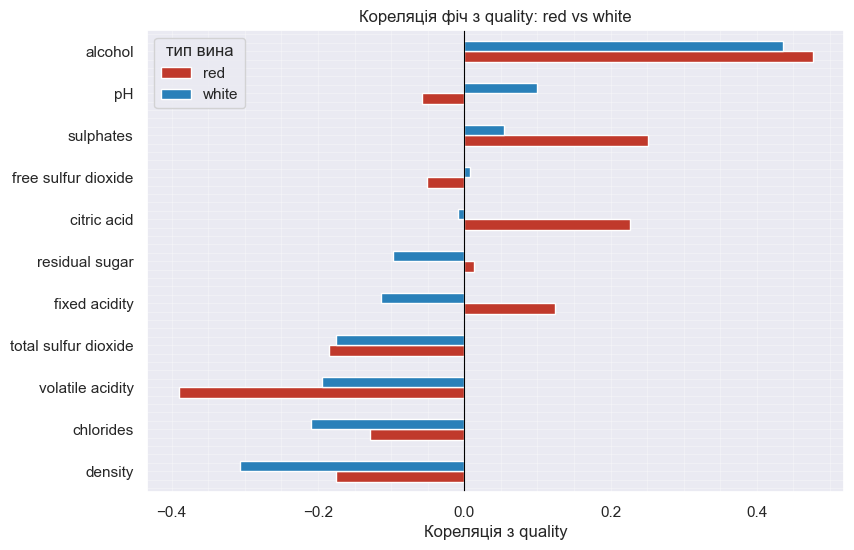

In [6]:
# Чи однаково фічі впливають на quality в обох винах?
cr = red.corr()["quality"].drop("quality")
cw = white.corr()["quality"].drop("quality")
comp_corr = pd.DataFrame({"red": cr, "white": cw}).sort_values("white")

comp_corr.plot(kind="barh", figsize=(9, 6), color=["#c0392b", "#2980b9"])
plt.title("Кореляція фіч з quality: red vs white")
plt.xlabel("Кореляція з quality")
plt.axvline(0, color="black", linewidth=0.8)
plt.legend(title="тип вина")
plt.show()

In [7]:
# В обох винах на якість найбільше впливає те саме: alcohol підвищує оцінку, а density, volatile acidity і chlorides - знижують. Раз головне працює однаково, обидва вина спокійно можна описувати однією моделлю. Кілька слабких фіч (fixed acidity, residual sugar, citric acid, pH) у червоному й білому поводяться трохи по-різному, але вони майже не впливають на оцінку, тож великої проблеми це не створює - а трохи згладити це допоможе ознака type.

In [8]:
# Висновок аналізу: вина різні за хімією, але головні зв'язки з якістю спільні,
# тому об'єднуємо їх в один датасет і додаємо категоріальну фічу type
red["type"] = "red"
white["type"] = "white"
wine = pd.concat([red, white], ignore_index=True)
wine["quality"] = wine["quality"].astype("int8")  # оцінка 3-9, int8 цілком достатньо
wine.shape

(6497, 13)

In [9]:
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [10]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int8   
 12  type                  6497 non-null   object 
dtypes: float64(11), int8(1), object(1)
memory usage: 615.6+ KB


In [11]:
# Пропуски по колонках і типи даних (шукаємо категоріальні фічі)
pd.DataFrame({"пропуски": wine.isna().sum(), "тип": wine.dtypes})

,пропуски,тип
fixed acidity,0,float64
volatile acidity,0,float64
citric acid,0,float64
residual sugar,0,float64
chlorides,0,float64
free sulfur dioxide,0,float64
total sulfur dioxide,0,float64
density,0,float64
pH,0,float64
sulphates,0,float64


In [12]:
# Пропусків немає. 11 фізико-хімічних фіч - числові; єдина категоріальна - type (red/white), яку ми додали і яку далі треба буде закодувати в числа.

In [13]:
# Перевірка повних дублікатів рядків
wine.duplicated().sum()

np.int64(1177)

In [14]:
# Знайшли багато повністю однакових рядків. Це ризик для моделі: якщо однаковий рядок потрапить і в train, і в test, оцінка якості буде завищеною (витік даних). Перед поділом датасету ці дублікати варто прибрати.

count    6497.000000
mean        5.818378
std         0.873255
min         3.000000
25%         5.000000
50%         6.000000
75%         6.000000
max         9.000000
Name: quality, dtype: float64


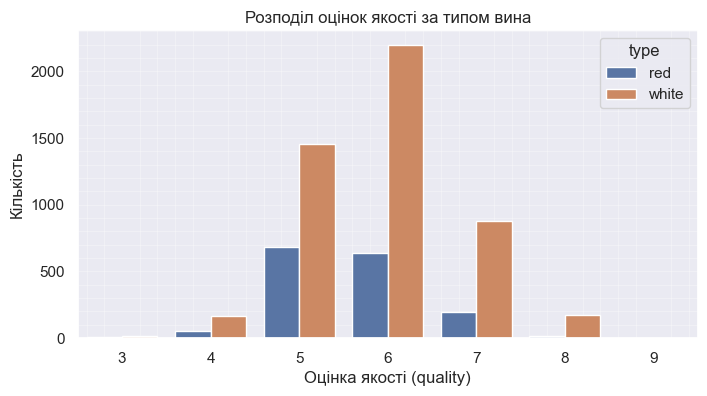

In [15]:
# Розподіл таргета quality
print(wine["quality"].describe())

plt.figure(figsize=(8, 4))
sns.countplot(x="quality", hue="type", data=wine)
plt.title("Розподіл оцінок якості за типом вина")
plt.xlabel("Оцінка якості (quality)")
plt.ylabel("Кількість")
plt.show()

In [16]:
# quality - ціле число, майже всі вина оцінені на 5-7, а дуже погані (3-4) і дуже добрі (8-9) трапляються рідко. Оцінки розподілені нерівномірно: середніх вин багато, тож модель краще вгадуватиме середні оцінки, а крайні - гірше. Для регресії розглядаємо quality як звичайне число.

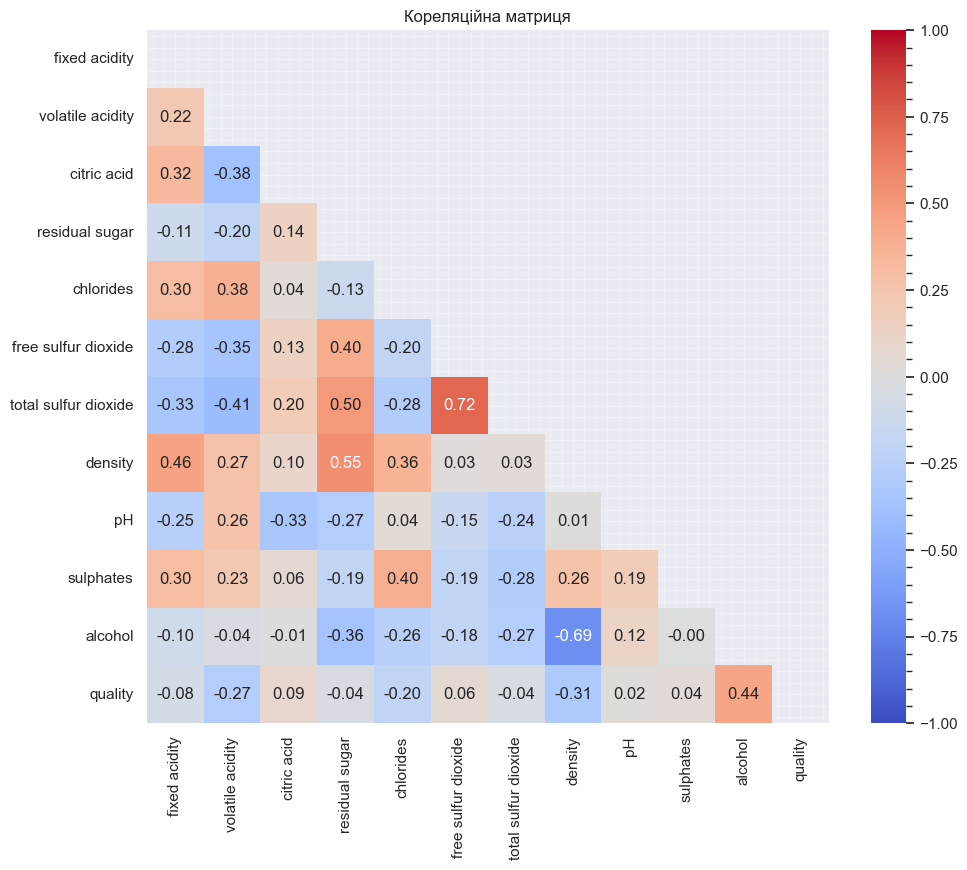

In [17]:
# Кореляція числових фіч між собою та з таргетом (на об'єднаних даних)
corr = wine.drop(columns="type").corr()

plt.figure(figsize=(11, 9))
mask = np.triu(corr)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, mask=mask)
plt.title("Кореляційна матриця")
plt.show()

In [18]:
# Найсильніше на оцінку впливає alcohol (міцніші вина оцінюють вище), трохи - density і volatile acidity (зі знаком мінус), решта фіч майже не впливають. Ще видно пари фіч, дуже схожих між собою (free і total sulfur dioxide, density і alcohol) - вони дублюють одне одного; це врахуємо пізніше, коли стримуватимемо ваги моделі.

In [19]:
# Крок 2. Фіча-інжиніринг
# 2.1 Кодуємо категоріальну фічу type у число (red=0, white=1)
wine["is_white"] = (wine["type"] == "white").astype("int8")

In [20]:
# 2.2 Нові фічі на основі доменної логіки
# free_sulfur_ratio - частка вільного (активного) SO2 від загального
wine["free_sulfur_ratio"] = wine["free sulfur dioxide"] / wine["total sulfur dioxide"]
# total_acidity - сумарна кислотність (об'єднує три скорельовані кислотні фічі в одну)
wine["total_acidity"] = wine["fixed acidity"] + wine["volatile acidity"] + wine["citric acid"]

wine[["is_white", "free_sulfur_ratio", "total_acidity", "quality"]].head()

,is_white,free_sulfur_ratio,total_acidity,quality
0,0,0.323529,8.10,5
1,0,0.373134,8.68,5
2,0,0.277778,8.60,5
3,0,0.283333,12.04,6
4,0,0.323529,8.10,5


In [21]:
# Перевіряємо, чи нові фічі несуть сигнал (кореляція з quality)
wine[["is_white", "free_sulfur_ratio", "total_acidity"]].corrwith(wine["quality"]).round(3)

is_white             0.119
free_sulfur_ratio    0.116
total_acidity       -0.094
dtype: float64

In [22]:
# Тип вина перетворили на число is_white (0/1). Нові фічі справді корисні: free_sulfur_ratio та is_white пов'язані з оцінкою навіть сильніше за більшість початкових фіч; total_acidity слабша, зате зручно зводить три схожі кислотні колонки в одну. Текстовий стовпець type більше не потрібен - приберемо його, коли готуватимемо дані для моделі.

In [23]:
# Крок 4. Поділ датасету на train / val / test (60/20/20)
# (масштабування робимо після поділу, щоб скейлер бачив лише train)

# Прибираємо повні дублікати (виявлені в Кроці 1), щоб однаковий рядок
# не потрапив одночасно в train і test (це давало б завищену оцінку)
wine_clean = wine.drop_duplicates().reset_index(drop=True)
print("було:", wine.shape[0], "-> після видалення дублікатів:", wine_clean.shape[0])

# Матриця ознак X (без текстового type і таргета) та таргет y
X = wine_clean.drop(columns=["quality", "type"])
y = wine_clean["quality"]
print("кількість ознак:", X.shape[1])
print(list(X.columns))

було: 6497 -> після видалення дублікатів: 5320
кількість ознак: 14
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'is_white', 'free_sulfur_ratio', 'total_acidity']


In [24]:
# Спочатку відділяємо test (20%), потім решту (80%) ділимо на train (60%) і val (20%)
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42)  # 0.25 * 0.8 = 0.2

print("train:", X_train.shape[0], "| val:", X_val.shape[0], "| test:", X_test.shape[0])

train: 3192 | val: 1064 | test: 1064


In [25]:
# Дублікати прибрано, тож однаковий рядок не потрапить у різні частини (немає витоку). Датасет поділено 60/20/20: train - для навчання, val - щоб порівнювати моделі й підбирати їх налаштування, test - фінальна чесна перевірка (не чіпаємо до самого кінця). Поділ випадковий, але з фіксованим random_state, щоб результат щоразу був однаковий.

In [26]:
# Крок 3. Масштабування фіч (StandardScaler)

scaler = StandardScaler()
# fit ЛИШЕ на train; val і test тільки трансформуємо (щоб не було витоку)
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_val_sc   = pd.DataFrame(scaler.transform(X_val),       columns=X.columns, index=X_val.index)
X_test_sc  = pd.DataFrame(scaler.transform(X_test),      columns=X.columns, index=X_test.index)

# Перевірка: на train середнє ~0, std ~1
X_train_sc.describe().round(2).loc[["mean", "std"]]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,is_white,free_sulfur_ratio,total_acidity
mean,0.0,-0.0,-0.0,0.0,0.0,-0.0,0.0,-0.0,0.0,0.0,-0.0,0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [27]:
# Скейлер навчений лише на train (середнє і розкид беруться звідти), а val і test тільки перераховуються - так немає витоку. Після масштабування кожна фіча на train має середнє ~0 і розкид ~1, тобто всі в однаковому масштабі. Це важливо для лінійних моделей: інакше фічі з великими числами (напр. total sulfur dioxide ~150) виглядали б "важливішими" за дрібні (pH ~3) просто через масштаб, а не через реальний вплив.

In [28]:
# Крок 5. Базова модель - LinearRegression з дефолтними гіперпараметрами

def evaluate(model, X, y, name):
    pred = model.predict(X)
    res = {"R2": r2_score(y, pred),
           "RMSE": mean_squared_error(y, pred) ** 0.5,
           "MAE": mean_absolute_error(y, pred)}
    print(f"{name:6} R2={res['R2']:.3f}  RMSE={res['RMSE']:.3f}  MAE={res['MAE']:.3f}")
    return res

lin = LinearRegression().fit(X_train_sc, y_train)
evaluate(lin, X_train_sc, y_train, "train")
baseline_val = evaluate(lin, X_val_sc, y_val, "val")

train  R2=0.318  RMSE=0.726  MAE=0.563
val    R2=0.297  RMSE=0.748  MAE=0.570


In [29]:
# Коефіцієнти базової моделі (на масштабованих фічах - їх можна порівнювати між собою)
pd.Series(lin.coef_, index=X.columns).sort_values()

density                -0.238100
volatile acidity       -0.225099
is_white               -0.053631
total sulfur dioxide   -0.032970
chlorides              -0.027956
free sulfur dioxide     0.002335
citric acid             0.029654
total_acidity           0.029879
fixed acidity           0.056755
pH                      0.089719
free_sulfur_ratio       0.096471
sulphates               0.127496
residual sugar          0.210103
alcohol                 0.293771
dtype: float64

In [30]:
# Базова модель пояснює ~30% розкиду якості (R2 на val = 0.30) - це в межах норми для лінійної регресії (0.25-0.4). train і val близькі (0.32 vs 0.30), тож перенавчання майже немає - модель проста. Середня помилка ~0.57 бала (MAE) при оцінках 3-9. Найбільший позитивний вплив має alcohol, найбільший негативний - density і volatile acidity, що збігається з кореляційним аналізом. Це наш орієнтир (baseline), з яким порівняємо регуляризовані моделі.

In [31]:
# Крок 6. Підбір гіперпараметрів (GridSearchCV) для регуляризованих моделей

search_spaces = {
    "Ridge": (Ridge(), {"alpha": [0.001, 0.01, 0.1, 1, 10, 100]}),
    "Lasso": (Lasso(max_iter=10000), {"alpha": [0.0001, 0.001, 0.01, 0.1, 1]}),
    "ElasticNet": (ElasticNet(max_iter=10000),
                   {"alpha": [0.001, 0.01, 0.1, 1], "l1_ratio": [0.1, 0.5, 0.9]}),
}

results = []
best_models = {}
for name, (estimator, grid) in search_spaces.items():
    gs = GridSearchCV(estimator, grid, scoring="r2", cv=5, n_jobs=-1)
    gs.fit(X_train_sc, y_train)
    best_models[name] = gs.best_estimator_
    val = evaluate(gs.best_estimator_, X_val_sc, y_val, name)
    print(f"       best params: {gs.best_params_}  (cv R2={gs.best_score_:.3f})")
    results.append({"model": name, "params": str(gs.best_params_),
                    "cv_R2": round(gs.best_score_, 3),
                    **{k: round(v, 3) for k, v in val.items()}})

Ridge  R2=0.296  RMSE=0.749  MAE=0.570
       best params: {'alpha': 100}  (cv R2=0.308)
Lasso  R2=0.297  RMSE=0.748  MAE=0.570
       best params: {'alpha': 0.001}  (cv R2=0.308)
ElasticNet R2=0.296  RMSE=0.749  MAE=0.570
       best params: {'alpha': 0.01, 'l1_ratio': 0.1}  (cv R2=0.308)


In [32]:
# Порівняння всіх моделей на валідації (включно з базовою)
comparison = pd.DataFrame(
    [{"model": "LinearRegression (baseline)", "params": "-", "cv_R2": np.nan,
      **{k: round(v, 3) for k, v in baseline_val.items()}}] + results
)
comparison

,model,params,cv_R2,R2,RMSE,MAE
0,LinearRegression (baseline),-,NaN,0.297,0.748,0.57
1,Ridge,{'alpha': 100},0.308,0.296,0.749,0.57
2,Lasso,{'alpha': 0.001},0.308,0.297,0.748,0.57
3,ElasticNet,"{'alpha': 0.01, 'l1_ratio': 0.1}",0.308,0.296,0.749,0.57


In [33]:
# Підбір налаштувань для всіх трьох моделей дав майже такий самий результат на val (R2 ~0.30), як у базової. Це логічно: базова модель і так не перенавчається (train ~ val), тож стримувати її ваги не було потреби. Для цих даних достатньо простої лінійної регресії - складніші варіанти переваги не дали.

In [34]:
# Обираємо фінальну модель за найкращим R2 на валідації (далі оцінимо її на test)
all_models = {"LinearRegression": lin, **best_models}
final_name = max(all_models, key=lambda n: r2_score(y_val, all_models[n].predict(X_val_sc)))
final_model = all_models[final_name]
print("Фінальна модель:", final_name)

Фінальна модель: LinearRegression


In [35]:
# Крок 7. Оцінка результатів - фінальна модель на ВСІХ трьох частинах
summary = pd.DataFrame({
    "train": evaluate(final_model, X_train_sc, y_train, "train"),
    "val":   evaluate(final_model, X_val_sc,   y_val,   "val"),
    "test":  evaluate(final_model, X_test_sc,  y_test,  "test"),
}).T.round(3)
summary

train  R2=0.318  RMSE=0.726  MAE=0.563
val    R2=0.297  RMSE=0.748  MAE=0.570
test   R2=0.309  RMSE=0.721  MAE=0.558


,R2,RMSE,MAE
train,0.318,0.726,0.563
val,0.297,0.748,0.570
test,0.309,0.721,0.558


In [36]:
# На test R2=0.31, RMSE=0.72, MAE=0.56 - майже як на train і val. Тобто на нових даних, яких модель не бачила, вона працює так само добре - перенавчання немає. У середньому модель помиляється приблизно на пів-бала (при оцінках 3-9).

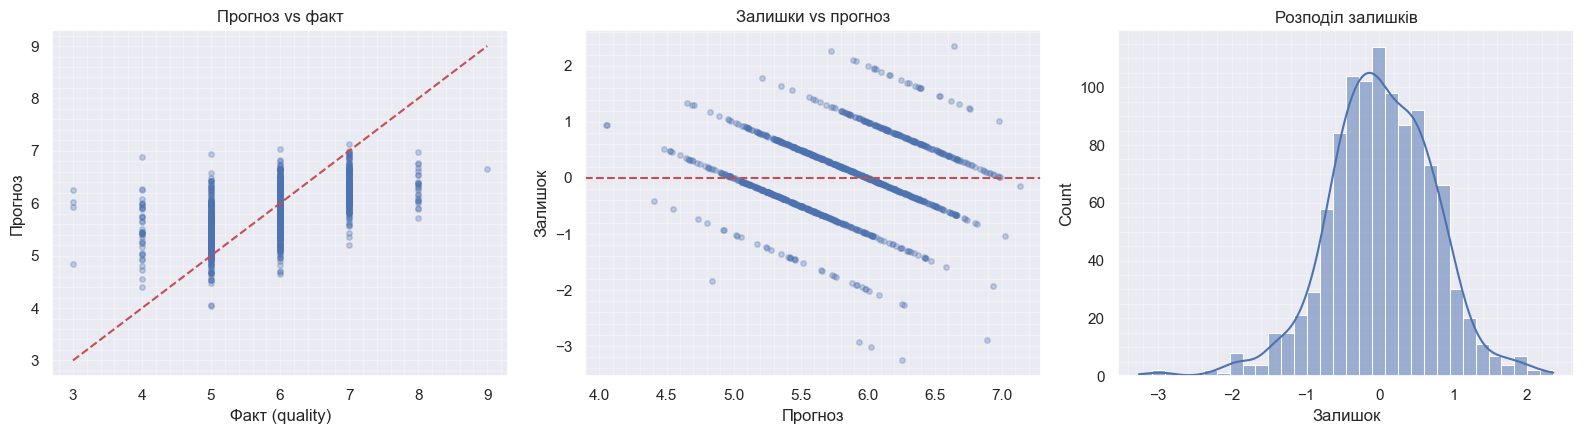

In [37]:
# Перевірка припущень лінійної регресії: дивимось на залишки
pred_test = final_model.predict(X_test_sc)
resid = y_test - pred_test

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].scatter(y_test, pred_test, alpha=0.3, s=15)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
axes[0].set_xlabel("Факт (quality)"); axes[0].set_ylabel("Прогноз"); axes[0].set_title("Прогноз vs факт")

axes[1].scatter(pred_test, resid, alpha=0.3, s=15)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_xlabel("Прогноз"); axes[1].set_ylabel("Залишок"); axes[1].set_title("Залишки vs прогноз")

sns.histplot(resid, kde=True, ax=axes[2])
axes[2].set_xlabel("Залишок"); axes[2].set_title("Розподіл залишків")

plt.tight_layout(); plt.show()

In [38]:
# Прогноз vs факт: точки йдуть уздовж діагоналі, але модель обережна - тримається середини, майже не ставить дуже низькі (3-4) чи дуже високі (8-9) оцінки (бо таких вин у даних мало). Залишки vs прогноз: помилки розкидані симетрично навколо нуля, без розширення в один бік - це добре. Самі помилки розподілені приблизно як дзвін (нормально). Тобто умови, за яких лінійна регресія працює коректно, в цілому виконуються.

In [39]:
# ПІДСУМОК: ми побудували лінійну регресію, яка передбачає оцінку вина за його хімічними показниками. Вона пояснює приблизно 30% того, чим вина різняться за оцінкою, і в середньому помиляється десь на пів-бала. Причому однаково добре і на навчальних, і на нових даних - тобто модель не просто "зазубрила" приклади. Найбільше на оцінку впливає міцність (alcohol). А решту ~70% пряма лінія не вловлює: зв'язок між хімією вина та його оцінкою, схоже, складніший за пряму залежність, тож самою лінійною регресією високої точності тут не досягти.